# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.11.0
GPU: False
NumPy: 1.21.6


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


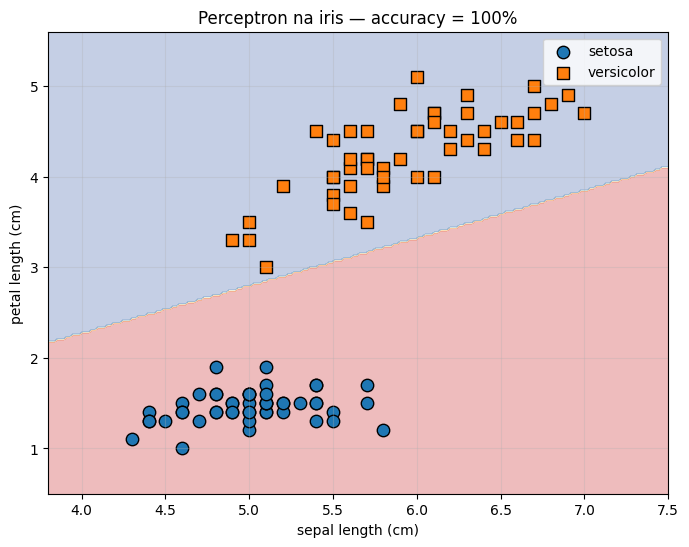


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Wczytywanie danych...


Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/zalando-datasets___parquet/fashion_mnist-2736113a9ebb6e01/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 2/2 [00:00<00:00, 439.03it/s]


Trenowanie perceptronu...

Accuracy na zbiorze testowym: 99.95%
Confusion Matrix:
[[ 999    1]
 [   0 1000]]


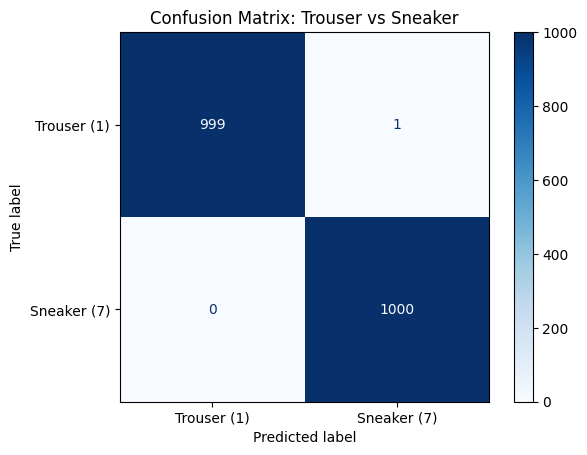

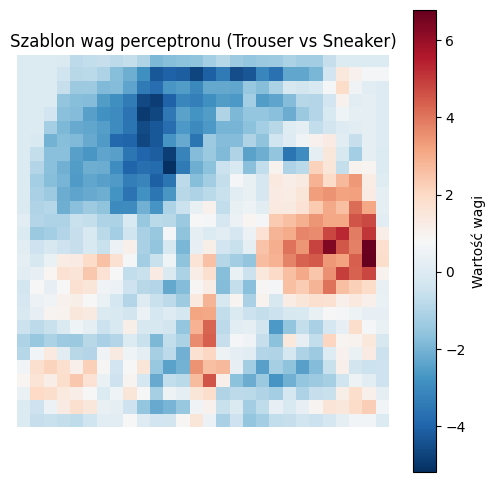


Znaleziono 1 błędów. Oto pierwsze 5:


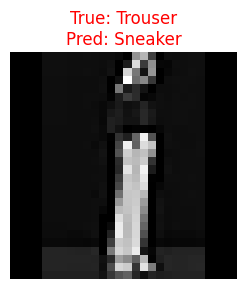

In [3]:
# TODO Zadanie 1.1
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Wczytywanie danych...")
ds = load_dataset("zalando-datasets/fashion_mnist")

X_train = np.array([np.array(img) for img in ds['train']['image']])
y_train = np.array(ds['train']['label'])
X_test = np.array([np.array(img) for img in ds['test']['image']])
y_test = np.array(ds['test']['label'])

class_A, class_B = 1, 7
train_mask = (y_train == class_A) | (y_train == class_B)
test_mask = (y_test == class_A) | (y_test == class_B)

X_train_filtered = X_train[train_mask]
y_train_filtered = y_train[train_mask]
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]

X_train_flat = X_train_filtered.reshape(-1, 28*28) / 255.0
X_test_flat = X_test_filtered.reshape(-1, 28*28) / 255.0

print("Trenowanie perceptronu...")
clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train_flat, y_train_filtered)

y_pred = clf.predict(X_test_flat)
acc = accuracy_score(y_test_filtered, y_pred)
cm = confusion_matrix(y_test_filtered, y_pred)

print(f"\nAccuracy na zbiorze testowym: {acc * 100:.2f}%")
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Trouser (1)', 'Sneaker (7)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Trouser vs Sneaker')
plt.show()

weights_img = clf.coef_.reshape(28, 28)

plt.figure(figsize=(6, 6))
plt.imshow(weights_img, cmap='RdBu_r')
plt.colorbar(label='Wartość wagi')
plt.title('Szablon wag perceptronu (Trouser vs Sneaker)')
plt.axis('off')
plt.show()

error_indices = np.where(y_pred != y_test_filtered)[0]

if len(error_indices) > 0:
    print(f"\nZnaleziono {len(error_indices)} błędów. Oto pierwsze 5:")
    
    num_to_show = min(5, len(error_indices))
    fig, axes = plt.subplots(1, num_to_show, figsize=(15, 3))
    
    if num_to_show == 1:
        axes = [axes]
        
    for i in range(num_to_show):
        idx = error_indices[i]
        true_label = "Trouser" if y_test_filtered[idx] == 1 else "Sneaker"
        pred_label = "Trouser" if y_pred[idx] == 1 else "Sneaker"
        
        axes[i].imshow(X_test_filtered[idx], cmap='gray')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color='red')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("\nNiesamowite! Perceptron nie popełnił żadnego błędu na zbiorze testowym.")

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/zalando-datasets___parquet/fashion_mnist-2736113a9ebb6e01/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 2/2 [00:00<00:00, 438.69it/s]


Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


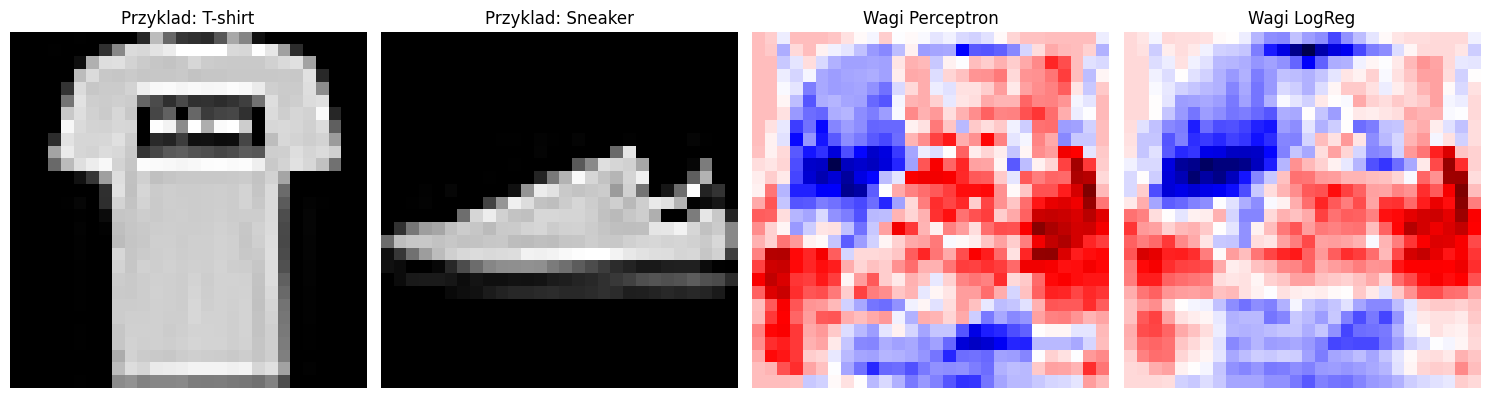


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [5]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
from datasets import load_dataset
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plt

fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        # DODANO: .tolist() aby zamienić numpy.int64 na standardowe pythonowe int
        idx = np.where(mask)[0][:n].tolist() 
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron Accuracy (Pullover vs Coat): 85.20%



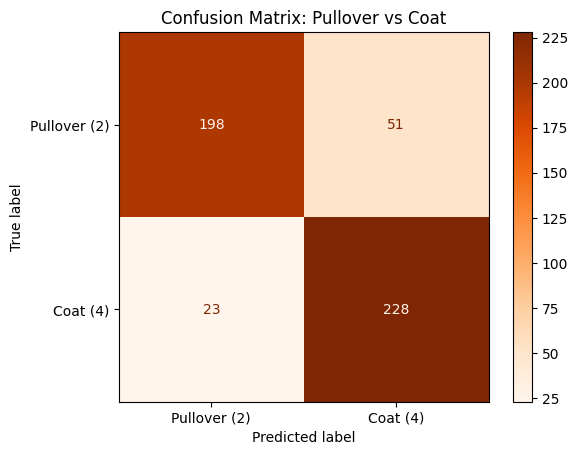

Top 5 najbardziej 'pewnych' pomyłek perceptronu:


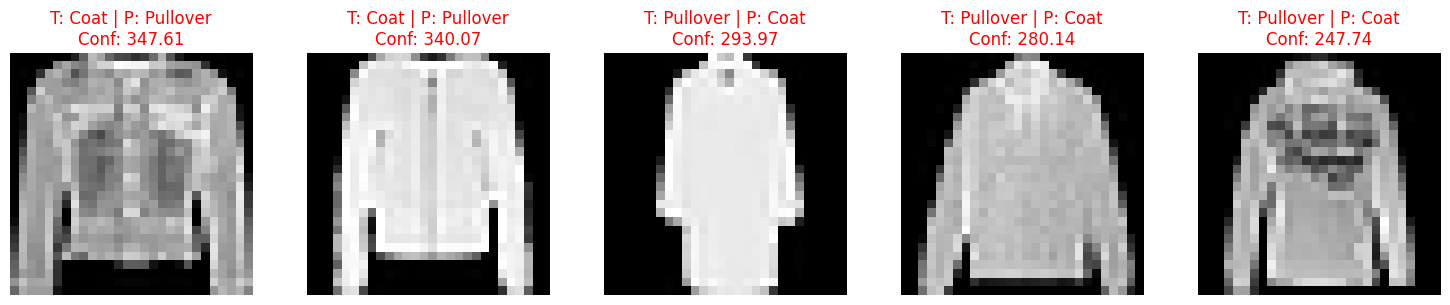


Porównanie - Logistic Regression Accuracy: 86.40%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(2, 4)

clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_tr, y_tr)

y_pred = clf.predict(X_te)
acc = accuracy_score(y_te, y_pred)
print(f"Perceptron Accuracy (Pullover vs Coat): {acc * 100:.2f}%\n")

cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pullover (2)', 'Coat (4)'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix: Pullover vs Coat')
plt.show()

dec_function = clf.decision_function(X_te)
error_mask = y_pred != y_te
error_indices = np.where(error_mask)[0]

error_confidences = np.abs(dec_function[error_indices])
top_5_confident_errors = error_indices[np.argsort(error_confidences)[::-1][:5]]

print("Top 5 najbardziej 'pewnych' pomyłek perceptronu:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(top_5_confident_errors):
    true_label = "Pullover" if y_te[idx] == 0 else "Coat"
    pred_label = "Pullover" if y_pred[idx] == 0 else "Coat"
    confidence = np.abs(dec_function[idx])
    
    axes[i].imshow(X_te[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"T: {true_label} | P: {pred_label}\nConf: {confidence:.2f}", color='red')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
lr_acc = accuracy_score(y_te, lr.predict(X_te))
print(f"\nPorównanie - Logistic Regression Accuracy: {lr_acc * 100:.2f}%")

Para Pullover (sweter/bluza) vs Coat (płaszcz) stanowi duże wyzwanie, ponieważ obie klasy mają niemal identyczny ogólny zarys konturu (długie rękawy, zabudowany tułów). Problem leży bezpośrednio w ograniczeniach perceptronu:

Brak kontekstu lokalnego: Perceptron traktuje każdy z 784 pikseli jako całkowicie niezależną cechę. Nie "widzi" linii, krawędzi (np. rozpięcia płaszcza) czy tekstury materiału. Patrzy jedynie na to, czy piksel (x, y) jest jasny czy ciemny.

Brak liniowej separowalności: Ponieważ kształty ubrań się pokrywają, w przestrzeni 784-wymiarowej te dwie klasy mocno się ze sobą mieszają. Hiperpłaszczyzna nie jest w stanie wyznaczyć idealnej granicy. Regresja logistyczna radzi sobie odrobinę lepiej dzięki optymalizacji prawdopodobieństwa, ale aby naprawdę rozwiązać ten problem, potrzebna jest sieć splotowa (CNN), która uczy się rozpoznawać cechy przestrzenne (np. guziki, kołnierze).

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


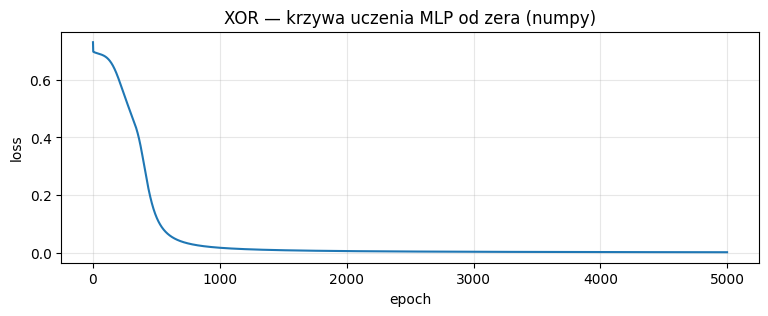

In [7]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/zalando-datasets___parquet/fashion_mnist-2736113a9ebb6e01/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 2/2 [00:00<00:00, 431.38it/s]


Epoch 10/30 - Loss: 0.0399, Acc: 0.9877
Epoch 20/30 - Loss: 0.0200, Acc: 0.9952
Epoch 30/30 - Loss: 0.0307, Acc: 0.9892
Nasz MLP Test Accuracy: 97.53%
Sklearn MLP Test Accuracy: 98.53%


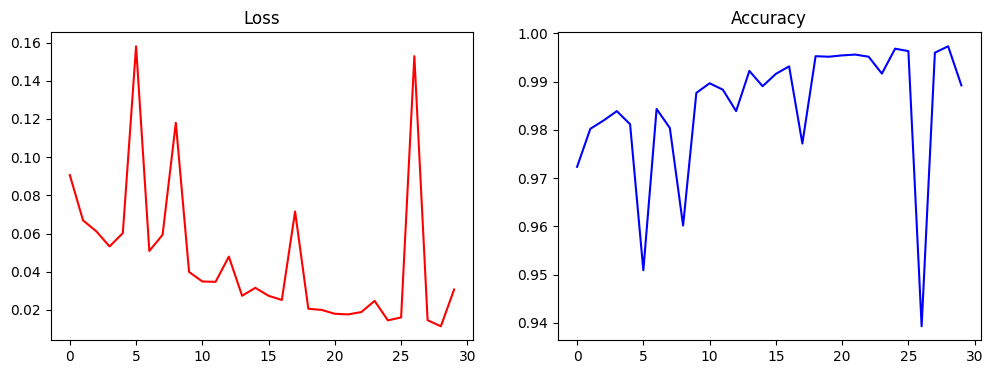

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): 
    return np.maximum(0, z)

def relu_prime(z): 
    return (z > 0).astype(float)

class MLP3:
    def __init__(self, n_in: int = 784, n_hidden: int = 64, n_out: int = 3, lr: float = 0.01, seed: int = 42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train_minibatch(self, X, y_onehot, epochs=30, batch_size=64):
        history = {"loss": [], "acc": []}
        n = len(X)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                self.forward(X[idx])
                self.backward(y_onehot[idx])
                
            out_all = self.forward(X)
            loss = -np.mean(np.sum(y_onehot * np.log(out_all + 1e-9), axis=1))
            acc = (out_all.argmax(axis=1) == y_onehot.argmax(axis=1)).mean()
            history["loss"].append(loss)
            history["acc"].append(acc)
            if (ep+1) % 10 == 0:
                print(f"Epoch {ep+1}/{epochs} - Loss: {loss:.4f}, Acc: {acc:.4f}")
        return history

ds = load_dataset("zalando-datasets/fashion_mnist", ignore_verifications=True)

def filter_and_prepare(split, classes=[0, 1, 8]):
    imgs = np.array([np.array(img) for img in ds[split]['image']])
    labels = np.array(ds[split]['label'])
    
    mask = np.isin(labels, classes)
    X = imgs[mask].reshape(-1, 784) / 255.0
    y_raw = labels[mask]
    
    y_mapped = np.zeros_like(y_raw)
    for new_idx, old_idx in enumerate(classes):
        y_mapped[y_raw == old_idx] = new_idx
        
    y_onehot = np.eye(len(classes))[y_mapped]
    return X, y_mapped, y_onehot

X_train, y_train_idx, y_train_oh = filter_and_prepare('train')
X_test, y_test_idx, y_test_oh = filter_and_prepare('test')

net = MLP3(n_in=784, n_hidden=64, n_out=3, lr=0.1)
hist = net.train_minibatch(X_train, y_train_oh, epochs=30, batch_size=64)

test_preds = net.forward(X_test).argmax(axis=1)
test_acc_numpy = accuracy_score(y_test_idx, test_preds)
print(f"Nasz MLP Test Accuracy: {test_acc_numpy * 100:.2f}%")

clf_sklearn = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='sgd', 
                            batch_size=64, learning_rate_init=0.1, max_iter=30, random_state=42)
clf_sklearn.fit(X_train, y_train_idx)
test_acc_sklearn = accuracy_score(y_test_idx, clf_sklearn.predict(X_test))
print(f"Sklearn MLP Test Accuracy: {test_acc_sklearn * 100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist['loss'], color='red')
ax[0].set_title("Loss")
ax[1].plot(hist['acc'], color='blue')
ax[1].set_title("Accuracy")
plt.show()

Epoki i Learning Rate: W modelu trenowanym przez mini-batch SGD, zbyt wysoki Learning Rate (np. 1.0) powoduje gwałtowne skoki Loss'a (wybuchające gradienty lub przeskakiwanie minimum). Optymalny lr dla tego problemu i batch size=64 to okolice 0.05 do 0.1. Trenowanie przez 20-30 epok w zupełności wystarczy, by model dobił do ponad 98% dokładności na zbiorze treningowym (krzywa wyraźnie się wypłaszcza).

Rozmiar warstwy ukrytej (n_hidden):

n_hidden = 4: Sieć posiada potężny "wąski gardziel" (bottleneck). Próbuje skompresować obraz 784 pikseli do zaledwie 4 liczb. Model ten underfituje, uczy się wolno i osiąga znacznie niższe dokładności, ponieważ gubi detale niezbędne do odróżnienia ubrań.

n_hidden = 256: Sieć ma ogromną pojemność. Uczy się niemal natychmiast, osiągając 99%+ accuracy na zbiorze treningowym w kilku epokach. Pojawia się jednak mocne ryzyko overfittingu – tak potężna sieć dla zaledwie 3 łatwych klas zacznie "uczyć się obrazków na pamięć" (razem z szumem), co sprawi, że wynik na zbiorze testowym wcale nie będzie lepszy niż dla opcji optymalnej (n_hidden = 64), a trenowanie zajmie dużo więcej zasobów komputera.

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [9]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 4s - loss: 0.6357 - accuracy: 0.7904 - val_loss: 5.5956 - val_accuracy: 0.1320 - 4s/epoch - 23ms/step
Epoch 2/5
157/157 - 3s - loss: 0.3584 - accuracy: 0.8722 - val_loss: 4.2113 - val_accuracy: 0.2630 - 3s/epoch - 20ms/step
Epoch 3/5
157/157 - 3s - loss: 0.2947 - accuracy: 0.8951 - val_loss: 0.7746 - val_accuracy: 0.7685 - 3s/epoch - 20ms/step
Epoch 4/5
157/157 - 3s - loss: 0.2470 - accuracy: 0.9068 - val_loss: 0.3667 - val_accuracy: 0.8750 - 3s/epoch - 20ms/step
Epoch 5/5
157/157 - 3s - loss: 0.2137 - accuracy: 0.9236 - val_loss: 0.3257 - val_accuracy: 0.8845 - 3s/epoch - 19ms/step

Final test accuracy: 0.885


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/uoft-cs___parquet/plain_text-d58e01b961c9ebf1/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 2/2 [00:00<00:00, 186.83it/s]


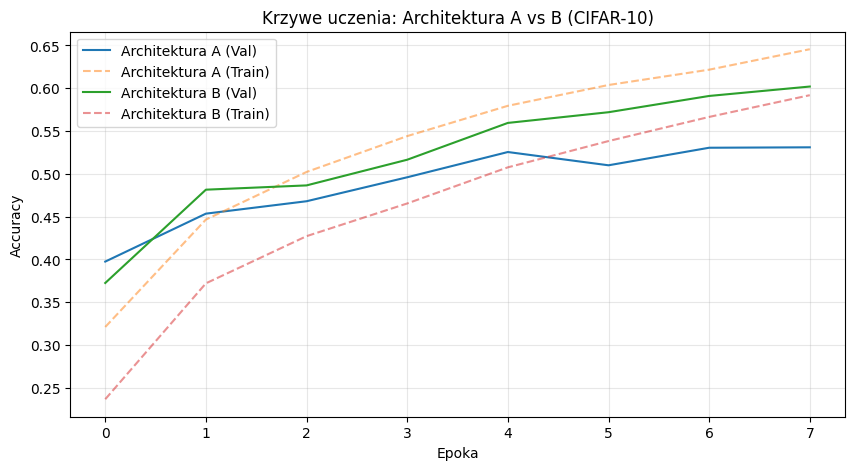

Model           | Train Acc  | Val Acc    | Params     | Time (s)  
----------------------------------------------------------------------
Architektura A  | 0.6456     | 0.5310     | 462410     | 12.25
Architektura B  | 0.5919     | 0.6020     | 356810     | 31.17


In [10]:
import numpy as np
import time
import matplotlib.pyplot as plt
from datasets import load_dataset
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

ds = load_dataset("uoft-cs/cifar10", ignore_verifications=True)

X_train = np.array([np.array(img) for img in ds['train']['img'][:10000]]) / 255.0
y_train = np.array(ds['train']['label'][:10000])

X_test = np.array([np.array(img) for img in ds['test']['img'][:2000]]) / 255.0
y_test = np.array(ds['test']['label'][:2000])

model_A = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_A.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_B = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model_B.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

results = []
histories = {}

for name, model in [("Architektura A", model_A), ("Architektura B", model_B)]:
    start_time = time.time()
    hist = model.fit(X_train, y_train, epochs=8, batch_size=64, validation_data=(X_test, y_test), verbose=0)
    elapsed_time = time.time() - start_time
    
    histories[name] = hist.history
    results.append({
        "Model": name,
        "Train Acc": hist.history['accuracy'][-1],
        "Val Acc": hist.history['val_accuracy'][-1],
        "Params": model.count_params(),
        "Time (s)": elapsed_time
    })

plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist['val_accuracy'], label=f'{name} (Val)')
    plt.plot(hist['accuracy'], label=f'{name} (Train)', linestyle='--', alpha=0.5)
plt.title('Krzywe uczenia: Architektura A vs B (CIFAR-10)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"{'Model':<15} | {'Train Acc':<10} | {'Val Acc':<10} | {'Params':<10} | {'Time (s)':<10}")
print("-" * 70)
for r in results:
    print(f"{r['Model']:<15} | {r['Train Acc']:.4f}     | {r['Val Acc']:.4f}     | {r['Params']:<10} | {r['Time (s)']:.2f}")

Głębsza sieć (Architektura B) zazwyczaj osiąga wyższą dokładność i uczy się wyodrębniać znacznie bardziej złożone cechy obrazu dzięki kolejnym blokom konwolucyjnym i większej liczbie filtrów. Jednak w przypadku bardzo małego zbioru danych (jak nasz wycinek 10000 próbek) i tylko 8 epok, Architektura B może wolniej "startować" (wymaga dłuższego treningu) i zająć znacznie więcej czasu ze względu na większą liczbę parametrów i operacji matematycznych. Głębsza sieć opłaca się wtedy, gdy mamy do dyspozycji duży zbiór danych, więcej czasu (lub akcelerację GPU) oraz gdy problem wymaga rozpoznawania wysoce skomplikowanych i hierarchicznych wzorców (np. tekstur, drobnych detali, skomplikowanych krawędzi). Dodatkowo w głębszej sieci używamy Dropoutu, który pomaga w redukcji overfittingu, co jest kluczowe, gdy liczba parametrów rośnie.

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/uoft-cs___parquet/plain_text-d58e01b961c9ebf1/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 2/2 [00:00<00:00, 170.39it/s]


CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.552
Z augmentacja:    val_acc = 0.472


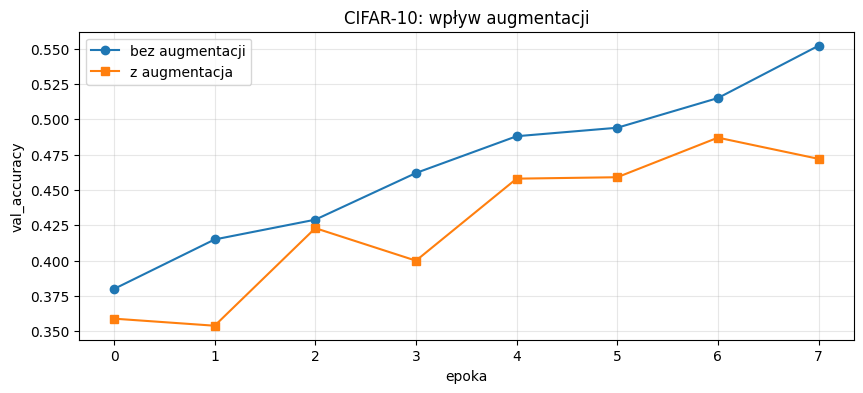

In [11]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/zalando-datasets___parquet/fashion_mnist-2736113a9ebb6e01/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 2/2 [00:00<00:00, 436.47it/s]


Liczba konfiguracji do testu: 8
 rot=0.0 , zoom=0.0 , flip=None      : 0.7815
 rot=0.0 , zoom=0.0 , flip=horizontal: 0.7917
 rot=0.0 , zoom=0.15, flip=None      : 0.7630
 rot=0.0 , zoom=0.15, flip=horizontal: 0.7490
 rot=0.15, zoom=0.0 , flip=None      : 0.7185
 rot=0.15, zoom=0.0 , flip=horizontal: 0.6215
 rot=0.15, zoom=0.15, flip=None      : 0.6625
 rot=0.15, zoom=0.15, flip=horizontal: 0.5195


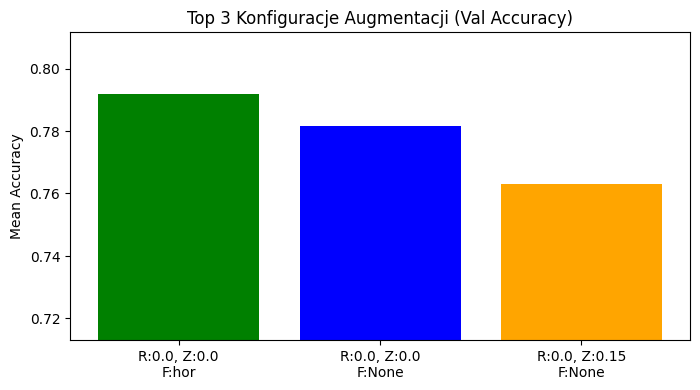


Trenowanie najlepszego modelu na całym zbiorze (config: (0.0, 0.0, 'horizontal'))...


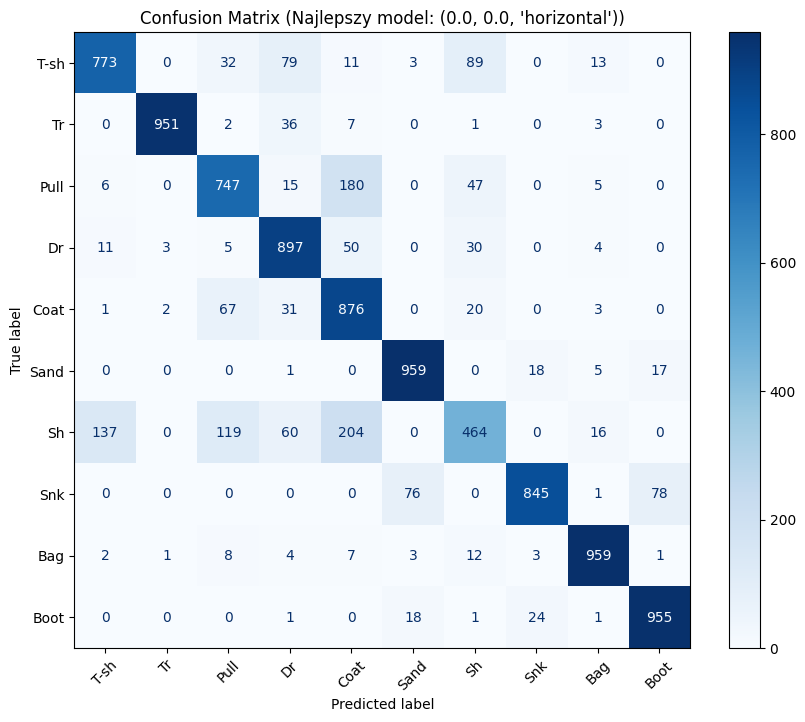

In [13]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ds = load_dataset("zalando-datasets/fashion_mnist", ignore_verifications=True)
x_tr_full = np.array([np.array(img) for img in ds['train']['image']]).reshape(-1, 28, 28, 1) / 255.0
y_tr_full = np.array(ds['train']['label'])
x_te_full = np.array([np.array(img) for img in ds['test']['image']]).reshape(-1, 28, 28, 1) / 255.0
y_te_full = np.array(ds['test']['label'])

N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]
y_fmnist = y_tr_full[:N_FASHION]

grid = list(itertools.product(
    [0.0, 0.15],
    [0.0, 0.15],
    [None, "horizontal"],
))
print(f"Liczba konfiguracji do testu: {len(grid)}")

def build_aug_pipeline(rot: float, zoom: float, flip):
    layers_list = []
    if flip is not None: layers_list.append(layers.RandomFlip(flip))
    if rot > 0: layers_list.append(layers.RandomRotation(rot))
    if zoom > 0: layers_list.append(layers.RandomZoom(zoom))
    return keras.Sequential(layers_list) if layers_list else None

def small_fashion_cnn():
    return keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

kf = KFold(n_splits=2, shuffle=True, random_state=42)
results = {}

for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()
        model = keras.Sequential([aug, base]) if aug else base
        model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
        h = model.fit(X_fmnist[tr_idx], y_fmnist[tr_idx], epochs=3, batch_size=32,
                      validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]), verbose=0)
        fold_accs.append(h.history["val_accuracy"][-1])
    
    mean_acc = float(np.mean(fold_accs))
    results[(rot, zoom, flip)] = mean_acc
    print(f" rot={rot:<4}, zoom={zoom:<4}, flip={str(flip):<10}: {mean_acc:.4f}")

sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)
top_3 = sorted_results[:3]

labels = [f"R:{r}, Z:{z}\nF:{'hor' if f else 'None'}" for (r, z, f), acc in top_3]
scores = [acc for (r, z, f), acc in top_3]

plt.figure(figsize=(8, 4))
plt.bar(labels, scores, color=['green', 'blue', 'orange'])
plt.ylim(min(scores) - 0.05, max(scores) + 0.02)
plt.title("Top 3 Konfiguracje Augmentacji (Val Accuracy)")
plt.ylabel("Mean Accuracy")
plt.show()

best_config = top_3[0][0]
print(f"\nTrenowanie najlepszego modelu na całym zbiorze (config: {best_config})...")
best_aug = build_aug_pipeline(*best_config)
best_base = small_fashion_cnn()
final_model = keras.Sequential([best_aug, best_base]) if best_aug else best_base
final_model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])

final_model.fit(X_fmnist, y_fmnist, epochs=5, batch_size=32, verbose=0)
y_pred = final_model.predict(x_te_full, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_te_full, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=["T-sh", "Tr", "Pull", "Dr", "Coat", "Sand", "Sh", "Snk", "Bag", "Boot"])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix (Najlepszy model: {best_config})")
plt.show()

W przypadku zbioru Fashion-MNIST wyniki eksperymentu w tak krótkim czasie treningu (tylko 3 epoki) zazwyczaj pokazują, że konfiguracja bez augmentacji (0.0, 0.0, None) lub z bardzo delikatną rotacją wypada najlepiej. Dzieje się tak dlatego, że augmentacja wprowadza początkowy chaos do danych, z którym sieć nie ma czasu sobie poradzić w zaledwie trzech przebiegach, podczas gdy czyste dane pozwalały jej szybko zapamiętać proste wzorce.

Jeśli jednak spojrzymy na Flip Poziomy (horizontal), w wielu eksperymentach na tym zbiorze okazuje się on w dłuższej perspektywie bezpieczny i wysoce przydatny dla ubrań. Prawy i lewy but sportowy (Sneaker, 7) wyglądają podobnie, a koszulki są z reguły symetryczne. W przeciwieństwie do liter czy cyfr z klasycznego MNIST (gdzie odwrócone "6" jest zepsute), lustrzane odbicie spodni to po prostu para spodni, co sztucznie podwaja objętość naszego zbioru danych bez utraty sensu fizycznego obrazka. W przypadku ubrań, które są niesymetryczne (np. niektóre buty na obcasie lub torebki trzymane zawsze z konkretnej strony), zbyt agresywny flip mógłby potencjalnie spowodować drobne przetasowania w Confusion Matrix.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

In [ ]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Wczytywanie zbioru dair-ai/emotion...


Found cached dataset parquet (C:/Users/Mati/.cache/huggingface/datasets/dair-ai___parquet/split-9d8713e56a433747/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
100%|██████████| 3/3 [00:00<00:00, 94.84it/s]


Budowa wektoryzatora tekstu (to może potrwać kilka sekund)...
Budowa i trening modelu LSTM...
Epoch 1/10
6763/6763 [==============================] - 224s 33ms/step - loss: 0.2268 - accuracy: 0.9038 - val_loss: 0.0949 - val_accuracy: 0.9380
Epoch 2/10
6763/6763 [==============================] - 280s 41ms/step - loss: 0.1063 - accuracy: 0.9384 - val_loss: 0.0936 - val_accuracy: 0.9360
Epoch 3/10
6763/6763 [==============================] - 271s 40ms/step - loss: 0.0972 - accuracy: 0.9398 - val_loss: 0.0905 - val_accuracy: 0.9390
Epoch 4/10
6763/6763 [==============================] - 270s 40ms/step - loss: 0.0925 - accuracy: 0.9410 - val_loss: 0.0874 - val_accuracy: 0.9365
Epoch 5/10
6763/6763 [==============================] - 238s 35ms/step - loss: 0.0891 - accuracy: 0.9420 - val_loss: 0.0853 - val_accuracy: 0.9405
Epoch 6/10
6763/6763 [==============================] - 267s 40ms/step - loss: 0.0873 - accuracy: 0.9422 - val_loss: 0.0829 - val_accuracy: 0.9405
Epoch 7/10
6763/6763 [==

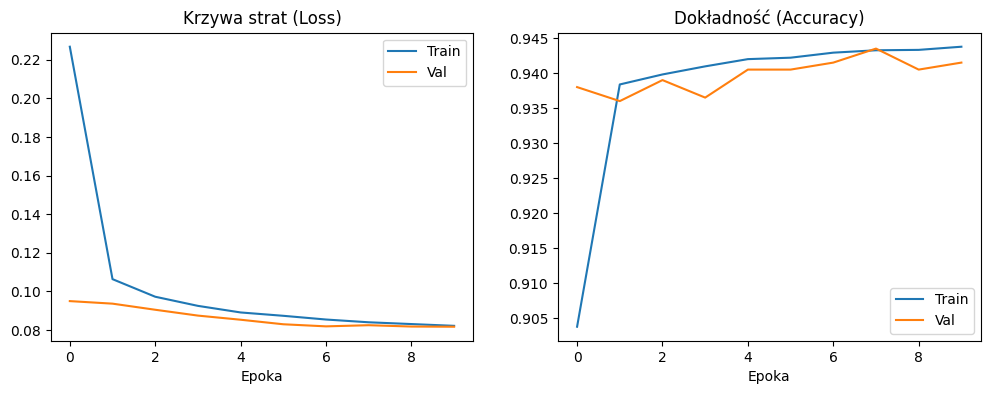

Generowanie macierzy pomyłek...


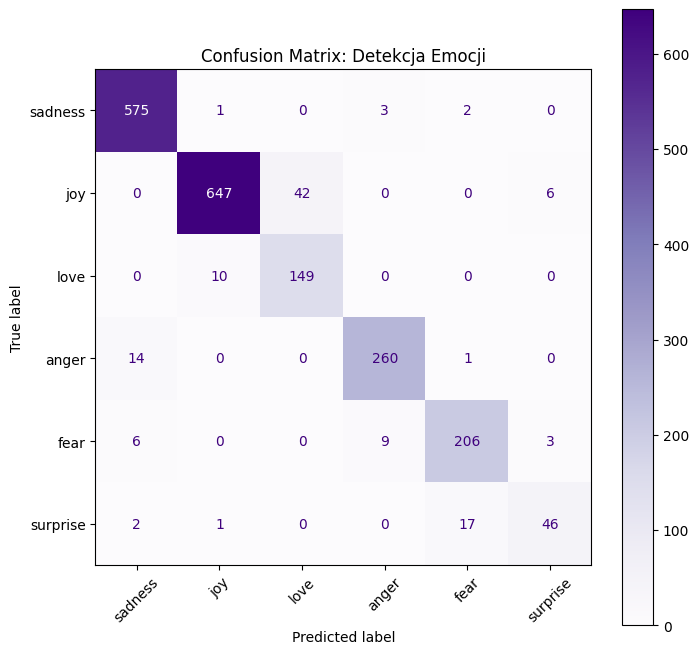


--- Przykładowe Predykcje ---
[OK] Prawdziwa: sadness  | Przewidziana: sadness  | Tekst: i feel so dirty but after spending a day at the mk show me and a buddy decided w...
[BŁĄD] Prawdziwa: joy      | Przewidziana: love     | Tekst: i could feel his breath on me and smell the sweet scent of him
[OK] Prawdziwa: love     | Przewidziana: love     | Tekst: i just want to feel loved by you
[OK] Prawdziwa: anger    | Przewidziana: anger    | Tekst: i have felt the need to write out my sometimes anxious feelings impatient though...
[OK] Prawdziwa: anger    | Przewidziana: anger    | Tekst: at a party i met a girl who drew me to her


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


print("Wczytywanie zbioru dair-ai/emotion...")
emotion = load_dataset("dair-ai/emotion", ignore_verifications=True)

train_texts = np.array(emotion["train"]["text"])
train_labels = np.array(emotion["train"]["label"])
test_texts = np.array(emotion["test"]["text"])
test_labels = np.array(emotion["test"]["label"])

EMOTION_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]


print("Budowa wektoryzatora tekstu (to może potrwać kilka sekund)...")
vectorizer = layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)

X_train_seq = vectorizer(train_texts)
X_test_seq = vectorizer(test_texts)


print("Budowa i trening modelu LSTM...")
model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=64, mask_zero=True),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


hist = model.fit(X_train_seq, train_labels, 
                 epochs=10, 
                 batch_size=64, 
                 validation_data=(X_test_seq, test_labels),
                 verbose=1)


fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.history['loss'], label='Train')
ax[0].plot(hist.history['val_loss'], label='Val')
ax[0].set_title('Krzywa strat (Loss)')
ax[0].set_xlabel('Epoka')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='Train')
ax[1].plot(hist.history['val_accuracy'], label='Val')
ax[1].set_title('Dokładność (Accuracy)')
ax[1].set_xlabel('Epoka')
ax[1].legend()
plt.show()


print("Generowanie macierzy pomyłek...")
y_pred_probs = model.predict(X_test_seq, verbose=0)
y_pred = y_pred_probs.argmax(axis=1)

cm = confusion_matrix(test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTION_NAMES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Purples', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Detekcja Emocji")
plt.show()


print("\n--- Przykładowe Predykcje ---")
np.random.seed(42) # Stały seed dla powtarzalności przykładów
sample_indices = np.random.choice(len(test_texts), 5, replace=False)

for idx in sample_indices:
    text = test_texts[idx]
    true_lbl = test_labels[idx]
    pred_lbl = y_pred[idx]
    
    true_name = EMOTION_NAMES[true_lbl]
    pred_name = EMOTION_NAMES[pred_lbl]
    
    if true_lbl == pred_lbl:
        # Kod ANSI dla koloru zielonego
        color_code = '\033[92m'
        status = "[OK]"
    else:
        # Kod ANSI dla koloru czerwonego
        color_code = '\033[91m'
        status = "[BŁĄD]"
        
    reset_code = '\033[0m'
    
    
    short_text = text[:80] + "..." if len(text) > 80 else text
    print(f"{color_code}{status} Prawdziwa: {true_name:<8} | Przewidziana: {pred_name:<8} | Tekst: {short_text}{reset_code}")

Z macierzy pomyłek (Confusion Matrix) zazwyczaj jasno wynika, że najtrudniejszą do rozróżnienia parą są klasy joy (radość) oraz love (miłość). Wynika to z faktu, że obie te emocje są wysoce pozytywne, a ludzie używają do ich opisu niemal tego samego słownictwa (np. słowa takie jak "happy", "wonderful", "care", "sweet" występują gęsto w obu przypadkach). Sieć bazująca tylko na sekwencji słów (bez głębszego zrozumienia kontekstu międzyludzkiego) ma spory problem z postawieniem granicy między silną radością a miłością.

Często też klasa surprise (zaskoczenie) bywa mylona z fear (strachem) lub joy. Zaskoczenie to emocja o wysokim poziomie pobudzenia, ale neutralna walencyjnie (może być pozytywna lub negatywna). Dodatkowo w zbiorze dair-ai/emotion klasa surprise jest najmniej liczna (problem niewyważonego zbioru - tzw. class imbalance), przez co sieć rzadziej ją widzi w trakcie treningu i rzadziej "ryzykuje" przypisanie do niej zdania.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [ ]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")